# Tahap 3 — Case Retrieval
## CBR Sistem Analisis Putusan Narkotika

**Tujuan:** Temukan kasus lama yang paling mirip dengan query kasus baru.

**Pendekatan yang digunakan:**
- **Representasi Vektor:** TF-IDF (`TfidfVectorizer` dari scikit-learn)
- **Model Retrieval:** LinearSVC (Support Vector Machine) untuk klasifikasi label putusan
- **Similarity:** Cosine Similarity untuk menemukan top-k kasus mirip
- **Split data:** 70% train / 30% test

**Langkah:**
1. Build TF-IDF vectors dari corpus
2. Split data train/test
3. Latih model SVM
4. Implementasi fungsi `retrieve(query, k)`
5. Pengujian awal dengan 7 query + ground-truth

## 3.0 Setup

In [1]:
import os, json, pickle
import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm                      import LinearSVC
from sklearn.model_selection          import train_test_split, cross_val_score
from sklearn.metrics.pairwise         import cosine_similarity
from sklearn.preprocessing            import LabelEncoder
from sklearn.metrics                  import classification_report, accuracy_score

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
os.chdir(ROOT)
os.makedirs('models',    exist_ok=True)
os.makedirs('data/eval', exist_ok=True)
print(f'Working directory: {ROOT}')

Working directory: e:\ragil\semester 6\Penalaran Komputer\cbr_narkotika\cbr_narkotika


## 3.1 Load Data

In [2]:
df = pd.read_csv('data/processed/cases.csv', encoding='utf-8-sig')

# Gabungkan field tekstual sebagai input model
df['text_repr'] = (
    df['ringkasan_dakwaan'].fillna('') + ' ' +
    df['ringkasan_fakta'].fillna('')   + ' ' +
    df['argumen_hukum'].fillna('')     + ' ' +
    df['pasal'].fillna('')             + ' ' +
    df['jenis_narkoba'].fillna('')
)

print(f'Dataset: {len(df)} kasus')
print(f'Distribusi label:\n{df["label_putusan"].value_counts().to_string()}')

Dataset: 35 kasus
Distribusi label:
label_putusan
penjara seumur hidup    22
pidana penjara          13


## 3.2 Representasi Vektor — TF-IDF

In [3]:
STOPWORDS_ID = [
    'yang','dan','di','ke','dari','untuk','dengan','pada','adalah','telah',
    'bahwa','atau','juga','ini','itu','tidak','ada','dalam','oleh','karena',
    'sebagai','akan','dapat','lebih','serta','para','pihak','tersebut',
    'majelis','hakim','pengadilan','negeri'
]

vectorizer = TfidfVectorizer(
    max_features = 3000,
    ngram_range  = (1, 2),      # unigram + bigram
    min_df       = 1,
    sublinear_tf = True,        # log(TF) untuk mengurangi dominasi term panjang
    stop_words   = STOPWORDS_ID,
)

tfidf_matrix = vectorizer.fit_transform(df['text_repr'].tolist())
print(f'TF-IDF matrix shape : {tfidf_matrix.shape}')
print(f'  - {tfidf_matrix.shape[0]} dokumen')
print(f'  - {tfidf_matrix.shape[1]} fitur (terms + bigrams)')

TF-IDF matrix shape : (35, 805)
  - 35 dokumen
  - 805 fitur (terms + bigrams)


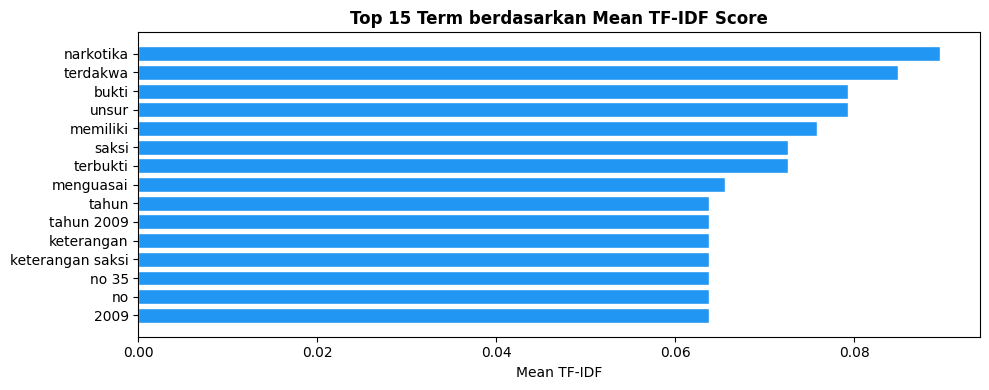

In [4]:
# Visualisasi top TF-IDF terms
feature_names = vectorizer.get_feature_names_out()
mean_tfidf    = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_idx       = np.argsort(mean_tfidf)[::-1][:15]

plt.figure(figsize=(10, 4))
plt.barh([feature_names[i] for i in top_idx][::-1],
         mean_tfidf[top_idx][::-1],
         color='#2196F3', edgecolor='white')
plt.title('Top 15 Term berdasarkan Mean TF-IDF Score', fontweight='bold')
plt.xlabel('Mean TF-IDF')
plt.tight_layout()
plt.savefig('data/eval/tfidf_top_terms.png', dpi=120)
plt.show()

## 3.3 Splitting Data (70:30)

In [5]:
le = LabelEncoder()
y  = le.fit_transform(df['label_putusan'].tolist())
print(f'Label classes: {le.classes_}')

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    tfidf_matrix, y, range(len(y)),
    test_size=0.30, random_state=42, stratify=y
)

print(f'\nTrain set : {X_train.shape[0]} sampel ({X_train.shape[0]/len(y)*100:.0f}%)')
print(f'Test  set : {X_test.shape[0]} sampel ({X_test.shape[0]/len(y)*100:.0f}%)')
print(f'Label distribusi train: {dict(zip(le.classes_, np.bincount(y_train)))}')
print(f'Label distribusi test : {dict(zip(le.classes_, np.bincount(y_test)))}')

Label classes: ['penjara seumur hidup' 'pidana penjara']

Train set : 24 sampel (69%)
Test  set : 11 sampel (31%)
Label distribusi train: {np.str_('penjara seumur hidup'): np.int64(15), np.str_('pidana penjara'): np.int64(9)}
Label distribusi test : {np.str_('penjara seumur hidup'): np.int64(7), np.str_('pidana penjara'): np.int64(4)}


## 3.4 Model Retrieval — LinearSVM

In [6]:
# Latih LinearSVC
clf = LinearSVC(C=1.0, max_iter=2000, random_state=42)
clf.fit(X_train, y_train)

# Evaluasi awal
y_pred_test  = clf.predict(X_test)
y_pred_train = clf.predict(X_train)

print(f'Train Accuracy : {accuracy_score(y_train, y_pred_train):.4f}')
print(f'Test  Accuracy : {accuracy_score(y_test, y_pred_test):.4f}')
print(f'\nClassification Report (Test Set):')
print(classification_report(y_test, y_pred_test, target_names=le.classes_, zero_division=0))

Train Accuracy : 1.0000
Test  Accuracy : 0.5455

Classification Report (Test Set):
                      precision    recall  f1-score   support

penjara seumur hidup       0.62      0.71      0.67         7
      pidana penjara       0.33      0.25      0.29         4

            accuracy                           0.55        11
           macro avg       0.48      0.48      0.48        11
        weighted avg       0.52      0.55      0.53        11



5-Fold CV Accuracy: 0.7143 ± 0.1278
Per-fold: [np.float64(0.5714), np.float64(0.8571), np.float64(0.5714), np.float64(0.8571), np.float64(0.7143)]


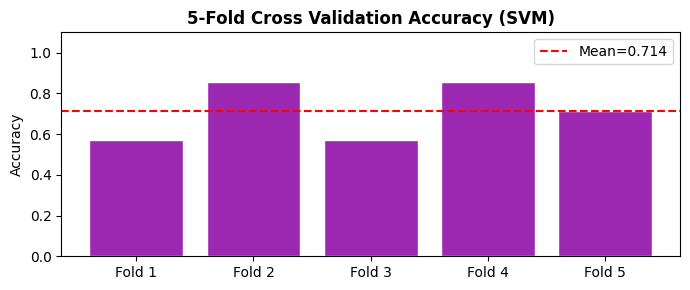

In [7]:
# Cross-Validation (5-fold)
from sklearn.model_selection import StratifiedKFold

cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(clf, tfidf_matrix, y, cv=cv, scoring='accuracy')

print(f'5-Fold CV Accuracy: {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'Per-fold: {[round(v,4) for v in cv_acc]}')

plt.figure(figsize=(7, 3))
plt.bar([f'Fold {i+1}' for i in range(5)], cv_acc,
        color='#9C27B0', edgecolor='white')
plt.axhline(cv_acc.mean(), color='red', linestyle='--',
            label=f'Mean={cv_acc.mean():.3f}')
plt.ylim(0, 1.1)
plt.title('5-Fold Cross Validation Accuracy (SVM)', fontweight='bold')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('data/eval/cv_accuracy.png', dpi=120)
plt.show()

## 3.5 Fungsi `retrieve(query, k)`

In [8]:
from typing import List

def retrieve(query: str, k: int = 5) -> List[int]:
    """
    Mencari top-k kasus paling mirip dengan query.

    Parameters
    ----------
    query : str  — Deskripsi kasus baru (teks bebas bahasa Indonesia)
    k     : int  — Jumlah kasus yang dikembalikan (default 5)

    Returns
    -------
    List[int] — Daftar case_id (1-indexed) terurut dari paling mirip
    """
    # 1. Pre-process query
    query_clean = query.lower()

    # 2. Hitung vektor TF-IDF query
    q_vec = vectorizer.transform([query_clean])

    # 3. Hitung cosine-similarity dengan semua case vectors
    sims  = cosine_similarity(q_vec, tfidf_matrix).flatten()

    # 4. Kembalikan top-k case_id
    top_k_idx  = np.argsort(sims)[::-1][:k]
    top_k_cids = [int(df.iloc[i]['case_id']) for i in top_k_idx]
    return top_k_cids, sims[top_k_idx].tolist()

# ── Demo ──
query_demo = 'terdakwa memiliki sabu-sabu 50 gram pasal 112 narkotika golongan I tanpa izin'
top5, sims5 = retrieve(query_demo, k=5)

print(f'Query : "{query_demo}"\n')
print(f'{"Rank":<5} {"Case_ID":<9} {"Similarity":<12} {"Terdakwa":<22} {"Narkoba":<14} {"Label"}')
print('-' * 80)
for rank, (cid, sim) in enumerate(zip(top5, sims5), 1):
    row = df[df['case_id'] == cid].iloc[0]
    print(f'{rank:<5} {cid:<9} {sim:<12.4f} {row["terdakwa"]:<22} {row["jenis_narkoba"]:<14} {row["label_putusan"]}')

Query : "terdakwa memiliki sabu-sabu 50 gram pasal 112 narkotika golongan I tanpa izin"

Rank  Case_ID   Similarity   Terdakwa               Narkoba        Label
--------------------------------------------------------------------------------
1     22        0.3782       Vicky Andrianto        sabu-sabu      penjara seumur hidup
2     10        0.2654       Joko Susilo            sabu-sabu      penjara seumur hidup
3     34        0.2651       Hadi Wijaya            sabu-sabu      pidana penjara
4     1         0.2629       Ahmad Fauzi            sabu-sabu      pidana penjara
5     30        0.2621       Dani Saputra           sabu-sabu      pidana penjara


## 3.6 Pengujian Awal — 7 Query + Ground-Truth

In [9]:
TEST_QUERIES = [
    {'query_id':'Q001','query_text':'terdakwa memiliki sabu-sabu seberat 50 gram tanpa izin disita polisi',
     'expected_label':'pidana penjara','ground_truth_ids':[1, 30, 34]},
    {'query_id':'Q002','query_text':'terdakwa menyimpan ganja seberat 2 kilogram di rumah pasal 112 narkotika golongan I',
     'expected_label':'penjara seumur hidup','ground_truth_ids':[2, 11, 14, 25, 26]},
    {'query_id':'Q003','query_text':'terdakwa menjadi perantara jual beli heroin diancam pasal 114 narkotika',
     'expected_label':'pidana penjara','ground_truth_ids':[15, 27, 29]},
    {'query_id':'Q004','query_text':'terdakwa menguasai ekstasi MDMA lebih dari 5 gram bukan tanaman pasal 112 ayat 2',
     'expected_label':'penjara seumur hidup','ground_truth_ids':[18, 19, 21, 24]},
    {'query_id':'Q005','query_text':'terdakwa memiliki kokain bukan tanaman tanpa hak barang bukti disita kepolisian',
     'expected_label':'penjara seumur hidup','ground_truth_ids':[5, 6, 12, 20, 33]},
    {'query_id':'Q006','query_text':'permufakatan jahat jual beli narkotika pasal 132 bersama-sama',
     'expected_label':'pidana penjara','ground_truth_ids':[4, 11, 12, 16, 19]},
    {'query_id':'Q007','query_text':'terdakwa menanam ganja tanaman narkotika golongan I pasal 111',
     'expected_label':'pidana penjara','ground_truth_ids':[5, 14, 17, 27, 30, 32, 34]},
]

results = []
print(f'{"ID":<6} {"Hit@5":<8} {"P@5":<8} {"R@5":<8} {"F1@5":<8} {"Top-5 Retrieved"}')
print('-' * 70)

for q in TEST_QUERIES:
    top_k, sims_k = retrieve(q['query_text'], k=5)
    gt            = q['ground_truth_ids']
    hit           = int(any(c in gt for c in top_k))
    prec          = len(set(top_k) & set(gt)) / 5
    rec           = len(set(top_k) & set(gt)) / max(len(gt), 1)
    f1            = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
    pred_lbl      = le.inverse_transform(clf.predict(vectorizer.transform([q['query_text'].lower()])))[0]
    results.append({**q, 'top_k': top_k, 'similarities': sims_k,
                    'predicted_label': pred_lbl, 'hit': hit,
                    'precision': round(prec,4), 'recall': round(rec,4), 'f1': round(f1,4)})
    print(f"{q['query_id']:<6} {'✓' if hit else '✗':<8} {prec:<8.3f} {rec:<8.3f} {f1:<8.3f} {top_k}")

# Save queries.json
with open('data/eval/queries.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

hit5_avg = np.mean([r['hit'] for r in results])
print(f'\nHit@5 rata-rata: {hit5_avg:.3f}  ({int(hit5_avg*7)}/7 query berhasil)')
print('✓ queries.json tersimpan → data/eval/queries.json')

ID     Hit@5    P@5      R@5      F1@5     Top-5 Retrieved
----------------------------------------------------------------------
Q001   ✓        0.600    1.000    0.750    [22, 10, 34, 1, 30]
Q002   ✓        0.600    0.600    0.600    [25, 23, 26, 2, 7]
Q003   ✓        0.400    0.667    0.500    [8, 15, 29, 33, 13]
Q004   ✓        0.800    1.000    0.889    [19, 18, 24, 21, 16]
Q005   ✓        1.000    1.000    1.000    [6, 5, 12, 33, 20]
Q006   ✓        1.000    1.000    1.000    [12, 11, 4, 16, 19]
Q007   ✓        1.000    0.714    0.833    [14, 32, 17, 27, 5]

Hit@5 rata-rata: 1.000  (7/7 query berhasil)
✓ queries.json tersimpan → data/eval/queries.json


## 3.7 Simpan Model

In [10]:
pickle.dump(vectorizer, open('models/tfidf_vectorizer.pkl','wb'))
pickle.dump(clf,        open('models/svm_classifier.pkl','wb'))
pickle.dump(le,         open('models/label_encoder.pkl','wb'))
sp.save_npz('models/tfidf_matrix.npz', tfidf_matrix)

print('Model tersimpan:')
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}')
    print(f'  models/{f}  ({size/1024:.1f} KB)')

Model tersimpan:
  models/label_encoder.pkl  (0.4 KB)
  models/svm_classifier.pkl  (6.9 KB)
  models/tfidf_matrix.npz  (13.5 KB)
  models/tfidf_vectorizer.pkl  (32.7 KB)


## 3.8 Output Tahap 3

| Output | Lokasi |
|--------|--------|
| TF-IDF Vectorizer | `models/tfidf_vectorizer.pkl` |
| SVM Classifier | `models/svm_classifier.pkl` |
| Label Encoder | `models/label_encoder.pkl` |
| TF-IDF Matrix | `models/tfidf_matrix.npz` |
| Query + Ground-Truth | `data/eval/queries.json` |

✅ **Tahap 3 Selesai** — Lanjut ke `Tahap4_Solution_Reuse.ipynb`